In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from utils import load_neurons_table, load_synapses_position_transformed
from connectome_types import CONNECTOME_SYN_TABLE_PATH
from neuron_custom_features import calc_spines_features
from spines_utils import filter_valid_neuron_w_spines

In [3]:
neurons_df = load_neurons_table(use_column_manual_ct=True)
syn_df = load_synapses_position_transformed(base_syn_table_path=CONNECTOME_SYN_TABLE_PATH)
df, syn_with_tags = calc_spines_features(neurons_df, syn_df)
df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)

ex_df = df[df.clf_type == 'E']
inh_df = df[df.clf_type == 'I']

ex_df = df[df.clf_type == 'E']
inh_df = df[df.clf_type == 'I']

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:22<00:00, 60.92it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


In [4]:
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Arial'
features_small_font_size = 12

purples = ['#C4B5FD', '#A17EFC', '#7C3AED']
greens = ['#6EE7B7', '#34D399', '#10B981', '#059669', '#047857']
spiny_color = '#7C3AED'

scatter_palette = {
    '23P': spiny_color, '4P': purples[1], '5P-IT': purples[0],
    '5P-NP': greens[4], '5P-PT': greens[3], '6P-CT': greens[2],
    '6P-IT': greens[1], '6P-U': greens[0],
}

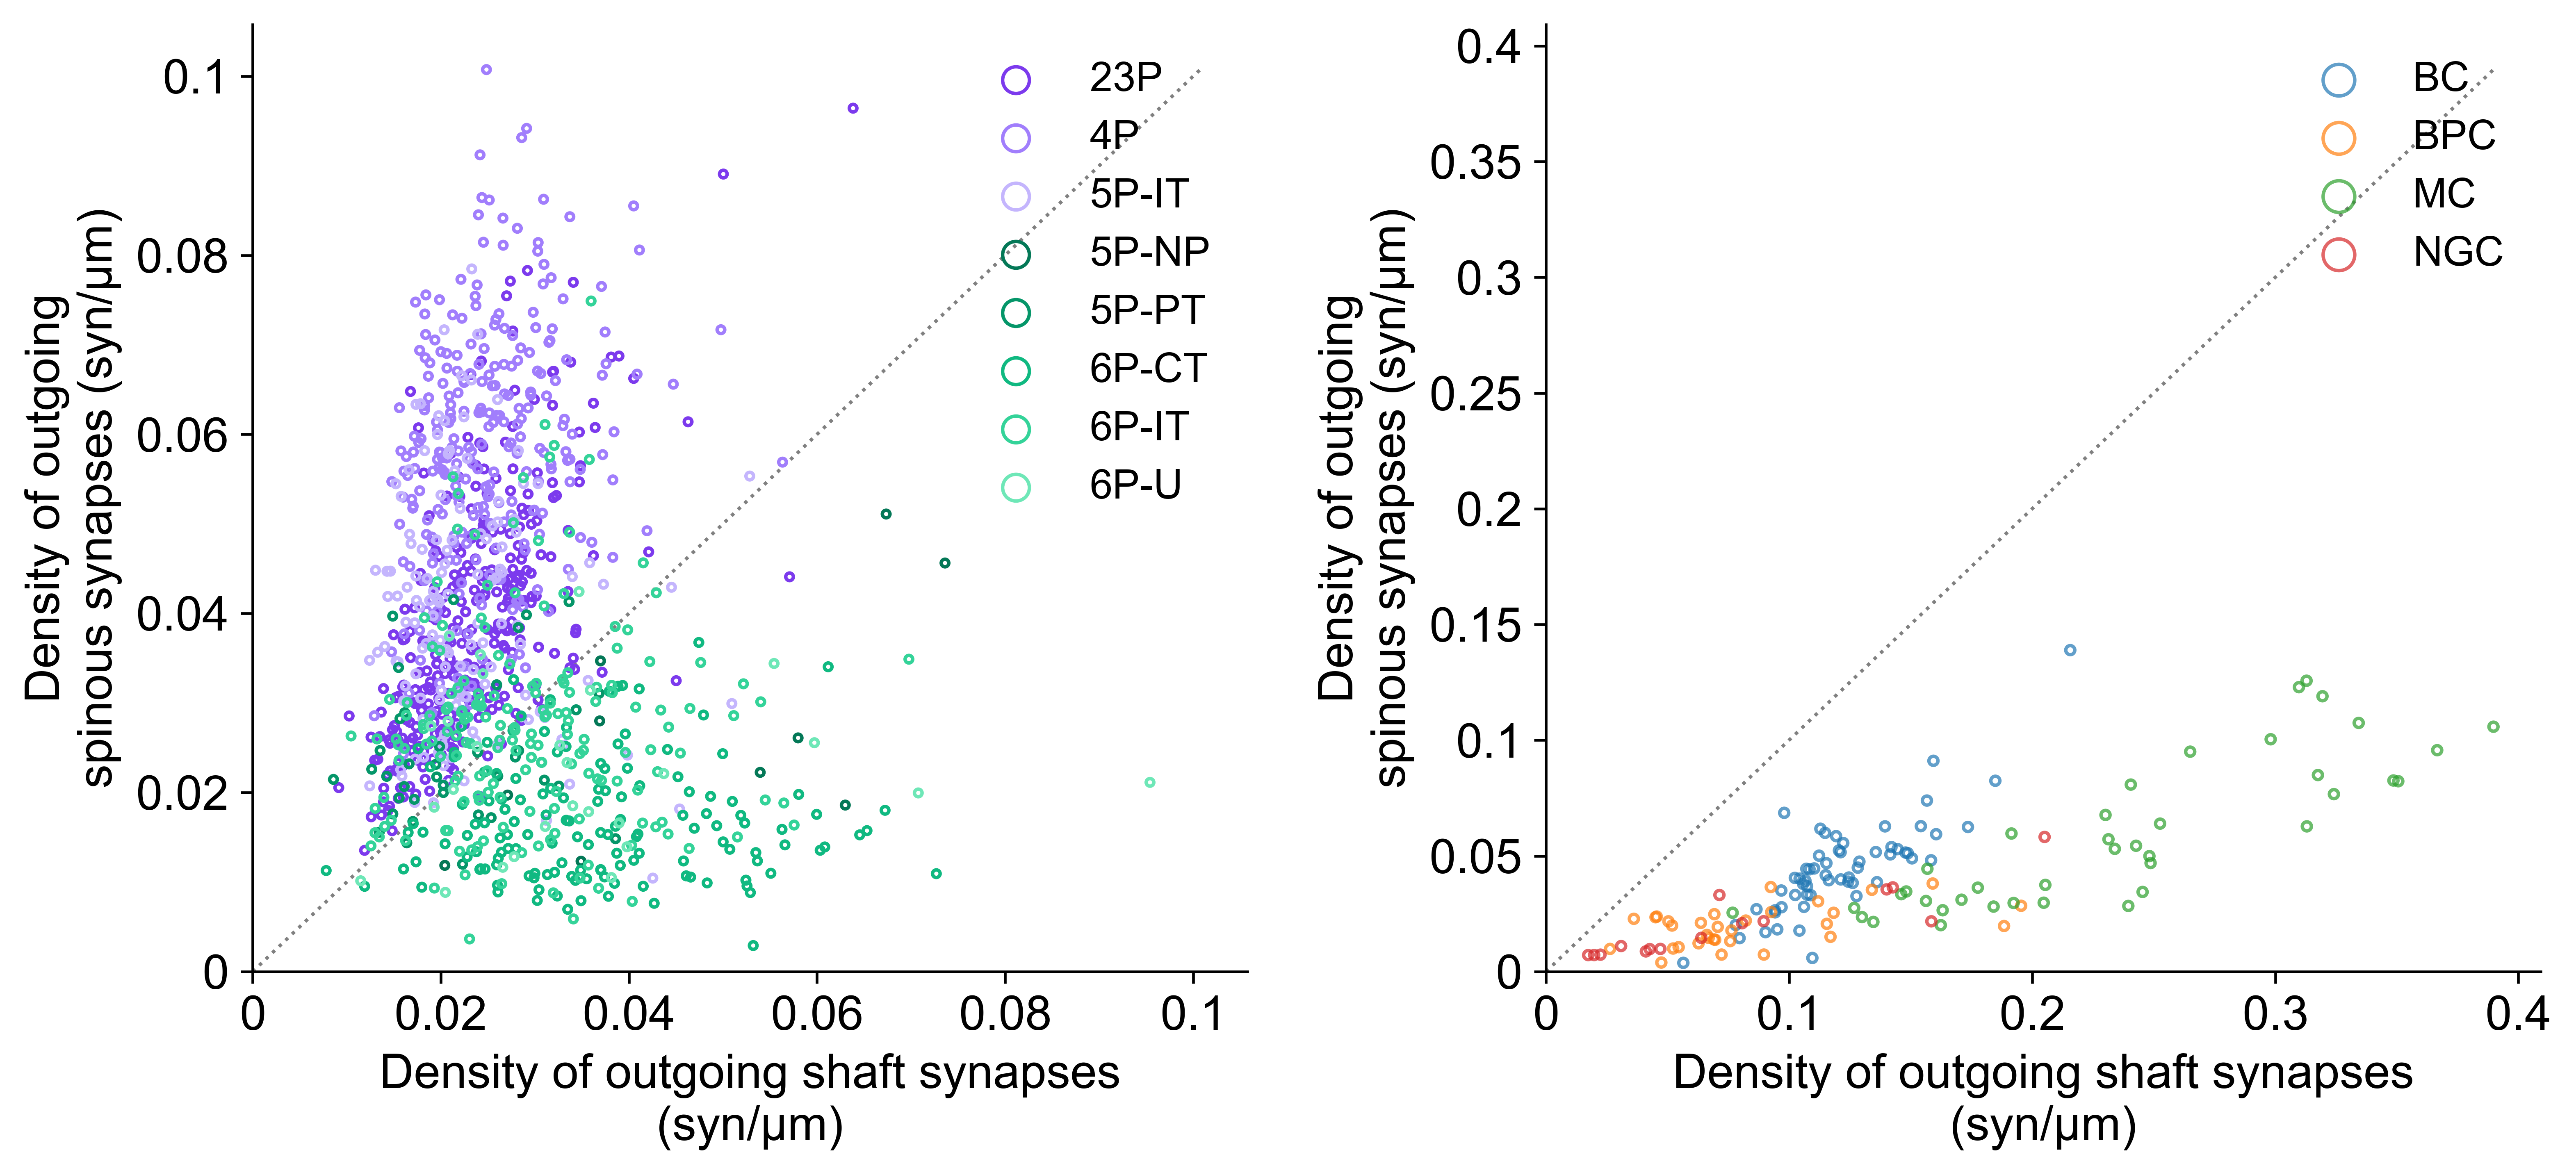

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 5), dpi=600, sharey=False)

ax = axes[0]
ex_neurons_sorted = ex_df.sort_values('cell_type')
ignore_cell_type = ['WM-P', 'Unsure E']
ex_neurons_sorted = ex_neurons_sorted[~ex_neurons_sorted['cell_type'].isin(ignore_cell_type)]
ex_neurons_sorted['cell_type'] = ex_neurons_sorted['cell_type'].cat.remove_unused_categories()

for c_type, color in [(ct, scatter_palette.get(ct, 'black')) for ct in ex_neurons_sorted['cell_type'].unique()]:
    subset = ex_neurons_sorted[ex_neurons_sorted['cell_type'] == c_type]
    ax.scatter(x=subset['ds_outgoing_shaft_density'], y=subset['ds_outgoing_spine_density'],
               edgecolors=[color], facecolors='none', s=5, alpha=1, label=c_type)
leg = ax.legend(title='', loc='upper right', frameon=False, markerscale=3.5,
                fontsize=features_small_font_size, ncol=1)
leg.set_zorder(4)

ax = axes[1]
inh_neurons_sorted = inh_df.sort_values('cell_type')
ignore_cell_type = ['Unsure I']
inh_neurons_sorted = inh_neurons_sorted[~inh_neurons_sorted['cell_type'].isin(ignore_cell_type)]
inh_neurons_sorted['cell_type'] = inh_neurons_sorted['cell_type'].cat.remove_unused_categories()

inh_colors = sns.color_palette(n_colors=len(inh_neurons_sorted['cell_type'].unique()))
for c_type, color in zip(inh_neurons_sorted['cell_type'].unique(), inh_colors):
    subset = inh_neurons_sorted[inh_neurons_sorted['cell_type'] == c_type]
    ax.scatter(x=subset['ds_outgoing_shaft_density'], y=subset['ds_outgoing_spine_density'],
               edgecolors=[color], facecolors='none', s=7, alpha=0.7, label=c_type)
leg = ax.legend(title='', loc='upper right', frameon=False, markerscale=3.5,
                fontsize=features_small_font_size, ncol=1)
leg.set_zorder(4)

max_density_ex = max(ex_neurons['ds_outgoing_shaft_density'].max(), ex_neurons['ds_outgoing_spine_density'].max())
axes[0].plot([0, max_density_ex], [0, max_density_ex], color='gray', linestyle=':', zorder=0, lw=1)

max_density_inh = max(inh_neurons['ds_outgoing_shaft_density'].max(), inh_neurons['ds_outgoing_spine_density'].max())
axes[1].plot([0, max_density_inh], [0, max_density_inh], color='gray', linestyle=':', zorder=0, lw=1)

for ax in axes:
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%g'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_xlabel('Density of outgoing shaft synapses\n(syn/\u03bcm)')
axes[0].set_ylabel('Density of outgoing\nspinous synapses (syn/\u03bcm)')
axes[1].set_xlabel('Density of outgoing shaft synapses\n(syn/\u03bcm)')
axes[1].set_ylabel('Density of outgoing\nspinous synapses (syn/\u03bcm)')

plt.subplots_adjust(wspace=0.3)
plt.savefig('fig_s12.pdf', format='pdf', bbox_inches='tight')